# 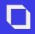 IONCOR Oy Scrap Value Forecasting Dashboard (Random Forest Regressor,XGBoost, ARIMA, LSTM, Prophet)

## 📦 Import, Load libraries and packages

In [1]:
import pandas as pd
import panel as pn
import matplotlib.pyplot as plt
from xgboost import XGBRegressor
from statsmodels.tsa.arima.model import ARIMA
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error
import warnings
warnings.filterwarnings("ignore")

pn.extension()

## 📁 Uploaded Files and Setup

In [2]:
file_dict = {
     "Cell_1_y7": "Cell_1_y7.XLSX",
    "BDU_Y7": "BDU_Y7.XLSX",
    "BMS_48": "BMS_48.XLSX",
    "Converter_48": "Converter_48.XLSX",
    "Base_Tray_vent_Y7": "Base_Tray_vent_Y7.XLSX",
    "BMU_Y7": "BMU_Y7.XLSX",
    "Cell_48": "Cell_48.XLSX",
    "Cooler_48": "Cooler_48.XLSX",
     "Busbar1_Y7": "Busbar1_Y7.XLSX",
    "Cover_Y7": "Cover_Y7.XLSX",
    "Cell_3_y7": "Cell_3_y7.XLSX",
    "Circuit_board_Sensor_48": "Circuit_board_Sensor_48.XLSX",
     "ZELLBLOCK_RE_Uki": "ZELLBLOCK_RE_Uki.XLSX",
    "ZELLBLOCK_LI_Uki": "ZELLBLOCK_LI_Uki.XLSX",
    "LI_ION_Cell_Uki": "LI_ION_Cell_Uki.XLSX",
    "Prismatic_Cell_Uki": "Prismatic_Cell_Uki.XLSX"
    
}


## ⚙️ Define Files and Preprocessing Function

In [3]:
def preprocess_time_series(file_path):
    df = pd.read_excel(file_path)
    df = df[["Posting Date", "Amount in LC"]]
    df = df.groupby("Posting Date").sum().reset_index()
    df = df.sort_values("Posting Date")
    df.dropna(inplace=True)
    return df

## 🧠 XGBoost Prediction

In [4]:
def xgboost_forecast(df):
    df['Year'] = df['Posting Date'].dt.year
    df['Month'] = df['Posting Date'].dt.month
    df['Day'] = df['Posting Date'].dt.day

    X = df[['Year', 'Month', 'Day']]
    y = df['Amount in LC']
    X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, shuffle=False)
    model = XGBRegressor(n_estimators=200, learning_rate=0.1)
    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)
    rmse = mean_squared_error(y_test, y_pred, squared=False)
    return y_test.reset_index(drop=True), y_pred, rmse

## 🔁 ARIMA Forecasting

In [5]:
def arima_forecast(df):
    series = df.set_index('Posting Date')['Amount in LC']
    model = ARIMA(series, order=(5,1,0))
    model_fit = model.fit()
    forecast = model_fit.forecast(steps=int(len(series)*0.2))
    y_true = series[-len(forecast):]
    rmse = mean_squared_error(y_true, forecast, squared=False)
    return y_true, forecast, rmse

## 📊 Plotting function

In [6]:
def create_plot(y_true, y_pred, model_name):
    plt.figure(figsize=(6,3))
    plt.plot(y_true.values, label='Actual')
    plt.plot(y_pred, label='Forecast')
    plt.title(f'{model_name} Forecast')
    plt.xlabel("Time")
    plt.ylabel("Scrap Value")
    plt.legend()
    return pn.pane.Matplotlib(plt.gcf(), tight=True)

## 🤖 Interactive Elements

In [7]:
component_selector = pn.widgets.Select(name='Select Component', options=list(file_dict.keys()))
xgb_plot_pane = pn.pane.Matplotlib()
arima_plot_pane = pn.pane.Matplotlib()
metrics_pane = pn.pane.Markdown()

## 🔁 Update function

Watcher(inst=Select(options=['Cell_1_y7', ...], value='Cell_1_y7'), cls=<class 'panel.widgets.select.Select'>, fn=<function update_dashboard at 0x00000206C34DEDE0>, mode='args', onlychanged=True, parameter_names=('value',), what='value', queued=False, precedence=0)

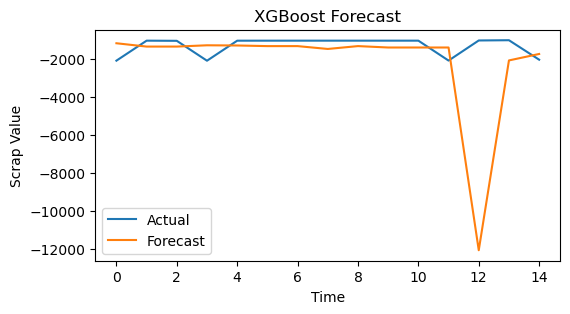

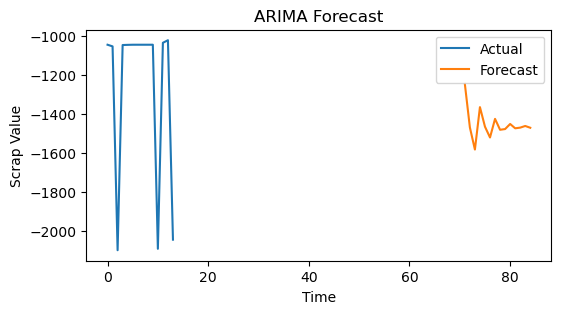

In [8]:
def update_dashboard(event=None):
    file_name = file_dict[component_selector.value]
    df = preprocess_time_series(file_name)
    y_test_xgb, y_pred_xgb, rmse_xgb = xgboost_forecast(df)
    y_test_arima, y_pred_arima, rmse_arima = arima_forecast(df)

    xgb_plot = create_plot(y_test_xgb, y_pred_xgb, "XGBoost")
    arima_plot = create_plot(y_test_arima, y_pred_arima, "ARIMA")

    xgb_plot_pane.object = xgb_plot.object
    arima_plot_pane.object = arima_plot.object

    metrics_md = f"""
    ### Forecasting Error Metrics
    - **XGBoost RMSE:** {rmse_xgb:.2f}
    - **ARIMA RMSE:** {rmse_arima:.2f}
    """
    metrics_pane.object = metrics_md
update_dashboard()  # Initial load
component_selector.param.watch(update_dashboard, 'value')

## 📉 Dashboard layout

Column
    [0] Markdown(str)
    [1] Select(options=['Cell_1_y7', ...], value='Cell_1_y7')
    [2] Matplotlib(Figure)
    [3] Matplotlib(Figure)
    [4] Markdown(str)
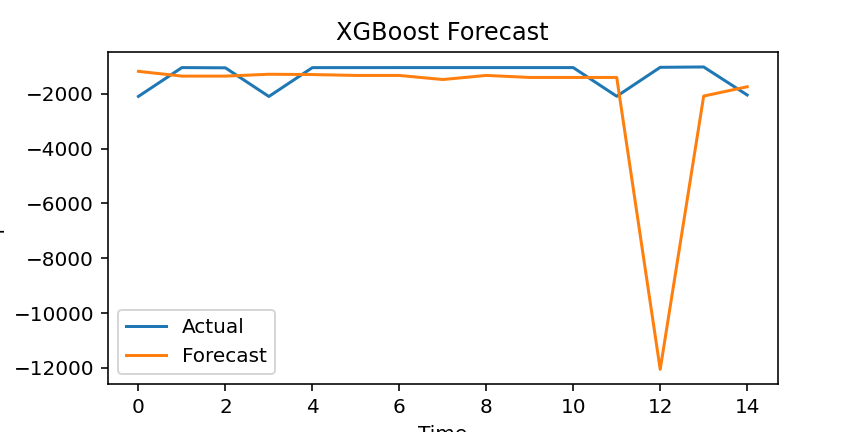
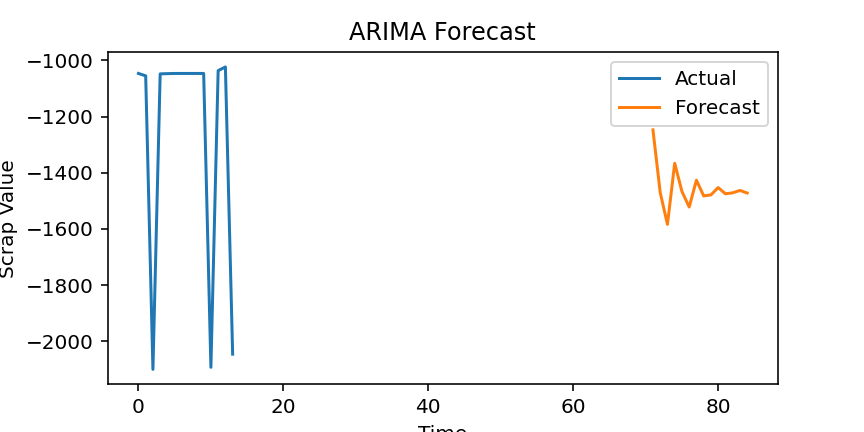

In [9]:
dashboard = pn.Column(
    "# Scrap Value Forecasting Dashboard",
    component_selector,
    xgb_plot_pane,
    arima_plot_pane,
    metrics_pane
)

dashboard.servable()